© Copyright, 2026 G. Schaer.

SPDX-License-Identifier: GPL-3.0-only

# The Single Axis Control Moment Gyroscope Problem

## Introduction

In this project, we are designing a controller to orient a model spacecraft about its yaw axis. To do so, we will be using a ***double-axis control moment gyroscope (CMG)*** comprised of a rolling outer ***gimbal***, a pitching inner gimbal, and a rapidly rotating ***flywheel***. The goal of the project is to determine how to rotate both gimbals so that the spacecraft points in a desired direction. To solve this problem, we are taking an approach called "model-based control". This means that our controller design will be based on a model of the dynamics of the system. The first step, then, is to use the Lagrangian mechanics formulation to derive the equations of motion. This project is similar to the last project in this series, but we have added an additional gimbal. Doing so extends the controllability of the system and allows us to orient objects without relying on a gravity force, like in the single-axis CMG project.

## The Process

To design a model-based controller, we will take 6 steps:
1. Determine the equations of motion of the system
2. Place the equations of motion in standard form
3. Linearize the standard form equations
4. Select a gain matrix that stablizes the system
5. Build a controller with our gain matrix
6. Simulate the system

## 1. System Dynamics and Equations of Motion

Let's derive a dynamic model of the CMG. From the diagram above, we see there are four major components, the spacecraft chassis, called $A$, the outer gimbal, called $B$, the inner gimbal, called $C$, and the flywheel, called $F$. There are three ***generalized coordinates*** for our system: the yaw of the spacecraft chassis, $\alpha$, the roll of the outer gimbal, $\beta$, and the pitch of the inner gimbal, $\gamma$. Additionally, a rolling and pitching torques, $\tau_\beta$ and $\tau_\gamma$, are applied to the outer gimbal and inner gimbals, respectively.

The first step in the Lagrangian mechanics approach to deriving the equations of motion of a system is to calculate the kinetic and potential energies of the system with respect to the generalized coordinates and their derivatives. We can do this using the Python package Sympy.

In [1]:
# Import everything we need from SymPy
import sympy as sym
import numpy as np
import scipy as sci
from sympy import Symbol, Matrix, Function, Derivative, N
from sympy import diff, simplify, trigsimp, sin, cos, solve, init_printing, symbols, lambdify
init_printing() # This function will make the outputs of SymPy look prettier and be easier to read

Now we are going to define the ***parameters*** of the system, that is, the system constants. All components have thier own moments of inertial: $I_A^A$ for the spacecraft chassis, $I_B^B$ for the outer gimbal, $I_C^C$ for the inner gimbal, and $I_F^C$ for the flywheel. Here, $I_j^k$ denotes the moment of inertia tensor of object $j$ in the inertial frame of object $k$. Additionally, the flywheel is spinning at a constant rotation rate, $\omega_F$.

In [2]:
# Define all the system parameters
omega_F = 62.8 # The angular rate of the flywheel
I_SS = np.array([[0.00828, 0, 0],
                 [0, 0.00828, 0],
                 [0, 0, 0.00828]]) # The moment of inertia of the spacecraft in kg-m^2 in its own frame

I_AA = np.array([[0.000937, 0, 0],
                 [0, 0.000476, 0],
                 [0, 0, 0.000476]]) # The moment of inertia of the A gimbal in kg-m^2 in its own frame
I_BB = np.array([[0.000937, 0, 0],
                 [0, 0.000476, 0],
                 [0, 0, 0.000476]]) # The moment of inertia of the B gimbal in kg-m^2 in its own frame

I_FaA = np.array([[0.00207, 0, 0],
                  [0, 0.00376, 0],
                  [0, 0, 0.00207]]) # The moment of inertia of the A flywheel in kg-m^2 in the A gimbal's inertial frame
I_FbB = np.array([[0.00207, 0, 0],
                  [0, 0.00376, 0],
                  [0, 0, 0.00207]]) # The moment of inertia of the B flywheel in kg-m^2 in the B gimbal's inertial frame

Now we make symbols and functions. These are elements of SymPy and can be thought of as exactly the same as symbols (variables) and functions from math.

In [3]:
# Time is a symbol (variable)
t = Symbol('t')

# The generalized coordinates and the inputs are both functions of time.
# This means that they are initialized as Functions.
phi_fn = Function('phi')     # The roll of the spacecraft
theta_fn = Function('theta') # The pitch of the spacecraft
psi_fn = Function('psi')     # The yaw of the spacecraft
gamma_fn = Function('gamma') # The angle of the gimbals
tau_gamma_fn = Function('tau_gamma') # The torque applied to the gimbals

Next up, we can start the process of defining the dynamics of the system. We begin by defining the set of rotation matrices that transform one inertial from to another inertial frame. After calculated, in the pursuit of calculating rotational energy, we use these transformation matrices to convert angular rates to angular velocities.

In [4]:
# Define the standard rotation matrices
R_x = lambda x : Matrix([[1, 0,       0     ],
                         [0, cos(x), -sin(x)],
                         [0, sin(x),  cos(x)]])
R_y = lambda x : Matrix([[ cos(x), 0, sin(x)],
                         [ 0,      1, 0     ],
                         [-sin(x), 0, cos(x)]])
R_z = lambda x : Matrix([[cos(x), -sin(x), 0],
                         [sin(x),  cos(x), 0],
                         [0,       0,      1]])

# Calculate the rotation matrices between the adjacent inertial frames
R_AS = R_z(gamma_fn(t))
R_BS = R_z(-gamma_fn(t))

In [5]:
# Get the angular velocities of each component in their own inertial frames
ang_vel_S_S = Matrix([diff(phi_fn(t), t), -diff(theta_fn(t), t), diff(psi_fn(t), t)])
ang_vel_A_A = Matrix([0, 0, diff(gamma_fn(t), t)]) + R_AS.T @ ang_vel_S_S
ang_vel_Fa_A = Matrix([0, omega_F, 0]) + ang_vel_A_A
ang_vel_B_B = Matrix([0, 0, -diff(gamma_fn(t), t)]) + R_BS.T @ ang_vel_S_S
ang_vel_Fb_B = Matrix([0, omega_F, 0]) + ang_vel_B_B

With the angular rates, we can calculate the rotational energies of the system. As well as the ***Langrangian***, which, in this case, is defined as the sum of the rotational energies (because there are not potential energies in this system).

In [6]:
# Get the rotational energies of each component
T_S = 0.5 * (ang_vel_S_S.T @ I_SS @ ang_vel_S_S)[0, 0]
T_A = 0.5 * (ang_vel_A_A.T @ I_AA @ ang_vel_A_A)[0, 0]
T_Fa = 0.5 * (ang_vel_Fa_A.T @ I_FaA @ ang_vel_Fa_A)[0, 0]
T_B = 0.5 * (ang_vel_B_B.T @ I_BB @ ang_vel_B_B)[0, 0]
T_Fb = 0.5 * (ang_vel_Fb_B.T @ I_FbB @ ang_vel_Fb_B)[0, 0]

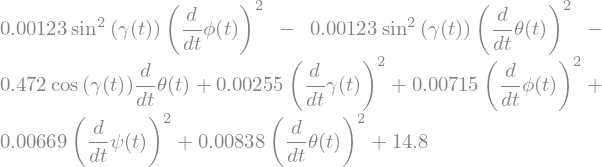

In [7]:
# Calculate the Lagrangian
L = simplify(trigsimp(T_S + T_A + T_Fa + T_B + T_Fb))
N(L,3)

Given the Lagrangian, the equations of motion of the system are defined via ***Euler-Lagrange equations*** with generalized forces:
$$\frac{d}{dt} \left( \frac{\partial L}{\partial \dot{q_j}} \right) - \frac{\partial L}{\partial q_j} = Q_j$$

Where $q_j$ is the $j$th generalized coordinate of the system and $Q_j$ are the non-conservative generalized forces acting on the $j$th generalized coordinate. For this system, then, the Euler-Lagrange equations take the form:

\begin{align}
\frac{d}{dt} \left( \frac{\partial L}{\partial \dot{\phi}} \right) - \frac{\partial L}{\partial \phi}&=0\\
\frac{d}{dt} \left( \frac{\partial L}{\partial \dot{\theta}} \right) - \frac{\partial L}{\partial \theta}&=0\\
\frac{d}{dt} \left( \frac{\partial L}{\partial \dot{\psi}} \right) - \frac{\partial L}{\partial \psi}&=0\\
\frac{d}{dt} \left( \frac{\partial L}{\partial \dot{\gamma}} \right) - \frac{\partial L}{\partial \gamma} - \tau_\gamma&=0
\end{align}

Solving these equations:

In [8]:
# Calculate the Euler-Lagrange equations
f_phi = diff(diff(L, Derivative(phi_fn(t), t)), t) - diff(L, phi_fn(t))
f_theta = diff(diff(L, Derivative(theta_fn(t), t)), t) - diff(L, theta_fn(t))
f_psi = diff(diff(L, Derivative(psi_fn(t), t)), t) - diff(L, psi_fn(t))
f_gamma = diff(diff(L, Derivative(gamma_fn(t), t)), t) - diff(L, gamma_fn(t)) - tau_gamma_fn(t)

In [9]:
# Solve each equation for the second order derivatives
soln = solve([f_phi, f_theta, f_psi, f_gamma], 
              Derivative(phi_fn(t), (t, 2)), 
              Derivative(theta_fn(t), (t, 2)), 
              Derivative(psi_fn(t), (t, 2)), 
              Derivative(gamma_fn(t), (t, 2)),)
soln = simplify(trigsimp(soln))
f_phi = soln[Derivative(phi_fn(t), (t, 2))]
f_theta = soln[Derivative(theta_fn(t), (t, 2))]
f_psi = soln[Derivative(psi_fn(t), (t, 2))]
f_gamma = soln[Derivative(gamma_fn(t), (t, 2))]

In [10]:
# Assemble the second order derivative equations
f = Matrix([f_phi, f_theta, f_psi, f_gamma])

# Replace the functions with symbols to make the system look prettier
(phidot, thetadot, psidot, gammadot,
 phi, theta, psi, gamma, tau_gamma) = symbols('phidot, thetadot, psidot, gammadot, phi, theta, psi, gamma, tau_gamma')
f = f.subs({Derivative(phi_fn(t), t) : phidot,
            Derivative(theta_fn(t), t) : thetadot,
            Derivative(psi_fn(t), t) : psidot,
            Derivative(gamma_fn(t), t) : gammadot,
            phi_fn(t) : phi,
            theta_fn(t) : theta,
            psi_fn(t) : psi,
            gamma_fn(t) : gamma,
            tau_gamma_fn(t) : tau_gamma,})

$$
\begin{bmatrix}
\ddot{\phi} \\
\ddot{\theta} \\
\ddot{\psi} \\
\ddot{\gamma} \\
\end{bmatrix} = 
\mathbf{f}\left(\dot{\phi}, \dot{\theta}, \dot{\psi}, \dot{\gamma}, \phi, \theta, \psi, \gamma, \tau_\gamma\right)
$$

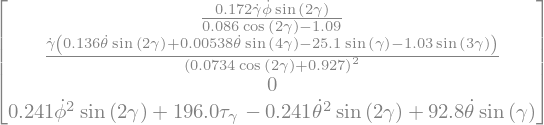

In [11]:
# Print the equations of motion
f = simplify(trigsimp(f))
N(f,3)

## 2. The Opposed Simplification

Notice that the numerator of the first equations of motion (relating to $\ddot{\phi}$) is multiplied by the roll rate, $\dot{\phi}$. Therefore, if the roll rate was $0$, then $\ddot{\phi}$ and $\ddot{\psi}$ would also both be zero. Suppose our system starts from an initial state where the roll rate and yaw rate are both $0$:

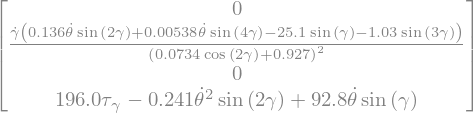

In [12]:
# Assume that the initial roll and yaw rates are 0 radians / second
f = f.subs({phidot : 0.0,})
f = simplify(trigsimp(f))
N(f,3)

From this initial condition, $\ddot{\phi}$ and $\dot{\phi}$ are both $0$, therefore, we know that the roll will remain at $0$ indefinitely. A similar argument can be made for the yaw rate, however in that case, $\ddot{\psi}$ is always $0$ regardless of initial condition. The stationary nature of the roll and yaw, coupled with the fact that neither $\ddot{\theta}$ nor $\ddot{\gamma}$ are dependent on the roll or yaw, effectively removes roll and yaw as the degrees of freedom of the system. As such, they may be dropped from the equations of motion.

This symmetry is caused by the opposed nature of the two control moment gyroscopes. As $A$ rotates counterclockwise, its flywheel's angular momentum vector rotates about the $+z$ axis, and as $B$ rotates clockwise (as enforced by the gears between them), its flywheel's angular momentum vector rotates about the $-z$ axis. This symmetric movement perfectly cancels reaction torques induced about all axes except the pitch axis.

$$
\begin{bmatrix}
\ddot{\theta} \\
\ddot{\gamma} \\
\end{bmatrix} = 
\mathbf{f}\left(\dot{\theta}, \dot{\gamma}, \theta, \gamma, \tau_\gamma \right)
$$

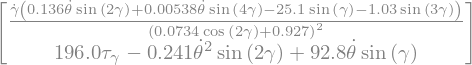

In [13]:
# Print the now simplified equations of motion
f = Matrix([f[1], f[3]])
N(f,3)

## 2. Standard Form

For model-based controls, a ***standard form*** of equations of motion is typically used:
$$
\dot{\mathbf{m}} = f(\mathbf{m}, \mathbf{n}),
$$

where $\mathbf{m}$ is the ***nonlinear state vector*** and $\mathbf{n}$ is the ***nonlinear input vector***.

There are two major differences between our current system and a system in standard form:
1. All the equations in our system are *second order*. Standard form requires all equations to be *first order*.
2. There are dervative arguments in our current system, $f$. Standard form requires that all arguments to $f$ are *zeroth order*. 

To fix problem 1, we need to replace both our *second order* differential equations with two *first order* differential equations. To do this, we can define three new variables: $\omega_{\alpha}$, $\omega_{\beta}$, and $\omega_\gamma$. We define these new variables via the differential equations:
\begin{align}
\dot{\alpha} &= \omega_{\alpha}, \\
\dot{\beta} &= \omega_{\beta},\\
\dot{\gamma} &= \omega_{\gamma}.\\
\end{align}

Now we expand our current system by appending these new differential equations to the end:
$$
\begin{bmatrix}
\ddot{\alpha} \\
\ddot{\beta} \\
\ddot{\gamma} \\
\dot{\alpha} \\ 
\dot{\beta} \\
\dot{\gamma}
\end{bmatrix} =
\begin{bmatrix}
f_{\alpha}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
f_{\beta}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
f_{\gamma}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
\omega_{\alpha} \\
\omega_{\beta} \\
\omega_{\gamma}
\end{bmatrix}.
$$

Next, by taking a derivative of our new differential equations, we find
\begin{align}
\ddot{\alpha} &= \dot{\omega}_{\alpha}, \\
\ddot{\beta} &= \dot{\omega}_{\beta}, \\
\ddot{\gamma} &= \dot{\omega}_{\gamma}, \\
\end{align}

Therefore, we can replace the second order differential equations with first order differential equations via a change of variables:
$$
\begin{bmatrix}
\dot{\omega_\alpha} \\
\dot{\omega_\beta} \\
\dot{\omega_\gamma} \\
\dot{\alpha} \\ 
\dot{\beta} \\
\dot{\gamma}
\end{bmatrix} =
\begin{bmatrix}
f_{\alpha}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
f_{\beta}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
f_{\gamma}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
\omega_{\alpha} \\
\omega_{\beta} \\
\omega_{\gamma}
\end{bmatrix}.
$$

This new system is a *first order* system of differential equations, which is what we wanted. To replicate this in code, we can do the following two steps:

In [14]:
# Define our new variables
(omega_theta, omega_gamma) = sym.symbols('omega_theta, omega_gamma')

# Add them to the system
f = sym.Matrix([f[0], omega_theta, f[1], omega_gamma])

Now we need to fix problem 2: there are dervative arguments in our current system. Standard form requires that all arguments to the system of differential equations are *zeroth order*. The good news is that we already have all the tools we need to correct this problem. To begin, note that the derivative arguments are in the functions
\begin{align}
f_{\alpha}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma), \\
f_{\beta}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma), \\
f_{\gamma}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma).
\end{align}

Recall that we have already created the variables $\omega_{\alpha}$, $\omega_{\beta}$, and $$\omega_{\gamma}$$ which are defined as
\begin{align}
\ddot{\alpha} &= \dot{\omega}_{\alpha}, \\
\ddot{\beta} &= \dot{\omega}_{\beta}, \\
\ddot{\gamma} &= \dot{\omega}_{\gamma}, \\
\end{align}
Therefore, to ensure all arguments to the system are *zeroth order*, we can simply replace every instance of $\dot{\alpha}$ and $\dot{\beta}$ with $\omega_{\alpha}$ and $\omega_{\beta}$, respectively. This results in a system with the form:
$$
\begin{bmatrix}
\dot{\omega_\alpha} \\
\dot{\omega_\beta} \\
\dot{\omega_\gamma} \\
\dot{\alpha} \\ 
\dot{\beta} \\
\dot{\gamma}
\end{bmatrix} =
\begin{bmatrix}
f_{\alpha}(\omega_\alpha, \omega_\beta, \omega_\gamma, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
f_{\beta}(\omega_\alpha, \omega_\beta, \omega_\gamma, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
f_{\gamma}(\omega_\alpha, \omega_\beta, \omega_\gamma, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
\omega_{\alpha} \\
\omega_{\beta} \\
\omega_{\gamma}
\end{bmatrix}.
$$

Every argument to this system is now *zeroth order*, which is what we wanted. To replicate this in code, we can do the following one step:

In [15]:
# Substitute the derivative terms with the new variables
f = f.subs({thetadot : omega_theta, 
            gammadot : omega_gamma,})

If we define the nonlinear state vector like this:
$$
\mathbf{m} = 
\begin{bmatrix}
{\omega}_{\alpha} \\
{\omega}_{\beta} \\
{\omega}_{\gamma} \\
{\alpha} \\ 
{\beta} \\
{\gamma}
\end{bmatrix},
$$
and the nonlinear input vector like this:
$$
\mathbf{n} = \begin{bmatrix} \tau_\beta \\ \tau_\gamma \end{bmatrix},
$$
then we can rewrite the system we have created like this:
$$
\dot{\mathbf{m}} = f(\mathbf{m},\mathbf{n})
$$
which is standard form.

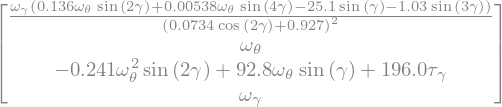

In [16]:
# Print the standard form equations of motion
f = simplify(trigsimp(f))
N(f,3)

## 3. Linearizing the System

Now we want to approximate the nonlinear system dynamics near an equilibrium point by linearizing the system to have the form
$$
\dot{\mathbf{x}} = A\mathbf{x} + B\mathbf{u},
$$
where $\mathbf{x}$ is the ***linear state vector*** and $\mathbf{u}$ is the ***linear input vector***. We call this model ***state space form***. There are three steps we take to convert our current nonlinear, standard form system of equations into state space form:
1. Choose an ***equilibrium point*** towards which the controller will drive the system.
2. Define $\mathbf{x}$ and $\mathbf{u}$.
3. Calculate $A$, also called the ***state matrix***.
4. Calculate $B$, also called the ***input matrix***.

Let's begin by finding an equilibrium point. An equilibrium point is any combination of nonlinear state, $\mathbf{m_{e}}$, and nonlinear input, $\mathbf{n_{e}}$, such that
$$
f(\mathbf{m_{e}}, \mathbf{n_{e}}) = 0.
$$
This is also called a ***stationary point*** because the time derivative of the nonlinear state vector—also called the nonlinear velocity vector—is exactly zero. Remember, we already have $f$, so all we need to do is find a valid $\mathbf{m_{e}}$ and $\mathbf{n_{e}}$. This equilibrium point will be the state that our controller drives the system towards, i.e., if our controller works, as time goes to infinity, the system will go to this equilibrium point. This is called ***stablization***. Accordingly, it would make sense to choose the equilibrium point where no torque is being applied ($\tau_\beta=\tau_\gamma=0$). Let's check to see how this limits the range of possible equilibrium points:

In [17]:
sub_expr = {omega_theta : 0.0, # To be stationary, all the derivative terms must be 0
            omega_gamma : 0.0, # To be stationary, all the derivative terms must be 0
            tau_gamma : 0.0, } # We want the torques to be 0 at equilibrium
equil_f = f.evalf(subs=sub_expr)
print('Equilibrium Condition:')
N(equil_f, 3)

Equilibrium Condition:


Evaluating the equations of motion, we find that these constraints guarantee an equilibrium point. This means that, as long as the inputs are 0, we can select any chassis or gimbal angles, $\alpha$, $\beta$, $\gamma$, we like and know we will have found an equilibrium point, i.e.,

\begin{align}
\forall \mathbf{m}_e\in \mathbb{R}^6\quad \text{such}\ \text{that}\quad f(\mathbf{m}_e, \mathbf{0})=\mathbf{0},\\
f(\mathbf{m}_e+\begin{bmatrix}0\\0\\0\\ a \\ b \\ c\end{bmatrix}, \mathbf{0})=\mathbf{0}\quad \forall a,b,c \in \mathbb{R}.
\end{align}

For now, let's select $\beta=\gamma=0$, but leave the chassis yaw, $\alpha$, unconstrained.

In [18]:
equilibrium_point = sub_expr = {omega_theta : 0.0,
                                omega_gamma : 0.0,
                                gamma : 0.5*np.pi,
                                tau_gamma : 0.0,}

Recall, in the previous project in this series we defined 
\begin{align}
\mathbf{x} &= \mathbf{m} - \mathbf{m_{e}}\\
\mathbf{u} &= \mathbf{n} - \mathbf{n_{e}}\\
A &= \left.\frac{\partial f}{\partial \mathbf{m}}\right|_{\mathbf{m_{e}}, \mathbf{n_{e}}}\\
B &= \left.\frac{\partial f}{\partial \mathbf{n}}\right|_{\mathbf{m_{e}}, \mathbf{n_{e}}}.\\
\end{align}
Doing so allows us to approximate our equations of motion $\dot{\mathbf{m}}=f(\mathbf{m},\mathbf{n})$ as
$$
\dot{\mathbf{x}} \approx A\mathbf{x} + B\mathbf{u},
$$
which is state space form. This state space representation can then be used to solve a ***linear quadratic problem*** to generate an optimal feedback controller. Let's calculate $A$ and $B$ now.

A=


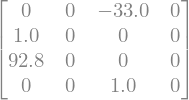

In [19]:
# First we define the nonlinear state vector
m = [omega_theta, theta, omega_gamma, gamma]

# Then we calculate the Jacobian of f with respect to the nonlinear state vector
A = f.jacobian(m)

# And finally, we evaluate the Jacbobian at the selected equilibrium point
A = A.evalf(subs=equilibrium_point)
print('A=')
N(A,3)

Note that the last three columns of $A$ are $\mathbf{0}$. Because of this, $A$ has the special property that, for all $a,b,c\in\mathbb{R}$,
$A\begin{bmatrix}0\\0\\0\\a\\0\\0\end{bmatrix}=A\begin{bmatrix}0\\0\\0\\0\\b\\0\end{bmatrix}=A\begin{bmatrix}0\\0\\0\\0\\0\\c\end{bmatrix}0$.

B=


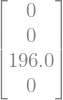

In [20]:
# First we define the nonlinear input vector
n = [tau_gamma]

# Then we calculate the Jacobian of f with respect to the nonlinear input vector
B = f.jacobian(n)

# And finally, we evaluate the Jacbobian at the selected equilibrium point
B = B.evalf(subs=equilibrium_point)
print('B=')
N(B,3)

Note that we did not define an equilibrium value for $\alpha$; however, neither $A$ nor $B$ are dependent on $\alpha$. This means that the linear approximation of the dynamics near $\omega_\alpha=\omega_\beta=\omega_\gamma=\beta=\gamma=\tau_\beta=\tau_\gamma=0$ is independent of the value of $\alpha$, i.e., for a given equilibrium point $(\mathbf{m}_e, \mathbf{n}_e)$, our state space model is just as accurate near $(\mathbf{m}_e, \mathbf{n}_e)$ as it is near the equilibrium point $(\mathbf{m}_e+\begin{bmatrix}0\\0\\0\\ a \\ 0 \\ 0\end{bmatrix}, \mathbf{n}_e)$, $a\in\mathbb{R}$. We showed above that $(\mathbf{m}_e+\begin{bmatrix}0\\0\\0\\ a \\ 0 \\ 0\end{bmatrix}, \mathbf{n}_e)$ is also an equilibrium point.

## 4. Controller Design

### 4a. Controllable and Uncontrollable Subspaces

Recall, our goal is to select a set of control inputs, $\mathbf{u}(t)$, that will drive the system, $(A, B)$, to the selected equilibrium state, $\mathbf{m}_e$. In the previous project in the CMG series, we already showed that, if our system is controllable, then we can find such a set of inputs. Let's check the controllability of our state space model now:

To calculate the ***controllability matrix***, $\mathcal{W}$, of our system, $(A,B)$, we can use `numpy`'s `hstack` function:

Controllability Matix:


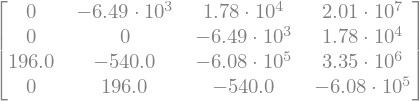

In [21]:
# Calculate the controllability matrix
ctrb = tuple(np.linalg.matrix_power(A,i) @ B for i in range(A.shape[0]))
ctrb = np.hstack(ctrb).astype(float)
print('Controllability Matix:')
N(Matrix(ctrb), 3)

Next, we will use `scipy.linalg`'s `svdvals` function to get the singular values, $s$, of the controllability matrix.

In [22]:
# Get the singular value decomposition of C
s = sci.linalg.svdvals(ctrb)

Finally, to determine if the system is controllable, we will ensure that the number of nonzero singular values is exactly equal to the number of states:

In [23]:
# Determine controllability by comparing the number of nonzero single values to the number of states
n_nonzero_singular_vals = np.sum(~np.isclose(s, 0)) # Account for numerical errors with np.isclose
is_controllable = n_nonzero_singular_vals == len(m)
print(f"Is Controllable: {is_controllable}")

Is Controllable: False


Because the number of nonzero singular values of $\mathcal{W}$ is *not* equal to the number of states, our system is *not* controllable. We can confirm this by printing the singular values:

Singular Values of the Controllability Matrix:


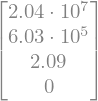

In [24]:
print('Singular Values of the Controllability Matrix:')
N(Matrix(np.round(s, 3)),3)

Our system, $(A, B)$, may not be controllable; however, this does not mean that there is not hope to control it. Previously we proved that a set of control inputs that drive the system to the selected equilibrium state will exist if the system is controllable, but we did not prove that, if the system is uncontrollable, no such set of inputs exist. Indeed, this is not the case.

In the previous project in this series, we proved that the span of the column vectors of the controllablity matrix defines the ***controllable subspace*** for our system $(A, B)$. Because one of the singular values of the controllability matrix is zero, we know that the column vectors do not not span the entirety of state space (which in this case is $\mathbb{R}^4$ because there are four states). Therefore, we conclude that there is a subspace of the state space we cannot control. We call this subspace the ***uncontrollable subspace*** of our system, $(A, B)$.

In this case, we can control a 3D subspace of the total 4D state space and not control a 1D subspace of the total 4D state space. In terms of eigenvalues, this is equivalent to saying that we can place three of the eigenvalues of the closed-loop response matrix anywhere we want, while the other one will remain in the same location no matter what gain matrix we choose. The eigenvalues we can place are often called ***controllable modes***, while the eigenvalues we can not place are often called or ***uncontrollable modes***.

Let's determine what the controllable and uncontrollable subspaces are for our system. Again, we know that the column vectors of the controllability matrix span the controllable subspace. `scipy`'s `linalg` module provides a function called `orth` that, given an input matrix, constructs an orthonormal basis for the ***range*** of the input matrix. In this case, range is another term for the span of the column vectors of a matrix. This gives us a method with which we can construct an orthogonal basis for the controllable subspace. Let's implement this now:

Controllable Subspace:


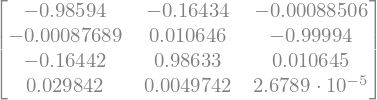

In [25]:
# Get a basis for the controllable subspace
basis_c = sci.linalg.orth(ctrb)
basis_c[abs(basis_c) <= 1.0e-6] = 0.0          # Correct numerical errors
basis_c = basis_c / np.sum(basis_c**2, axis=0) # Correct numerical errors
print("Controllable Subspace:")
N(Matrix(basis_c), 5)

As expected, the dimension of this space (the number of vectors in the basis set) is three, which is exactly equal to the number of controllable modes.

Next, let's look at the uncontrollable subspace of $(A, B)$. A common result from linear algebra is that, given an $m\times n$ matrix, the null space of the transpose of the matrix forms an orthogonal complement of the range of the matrix within the matrix's codomain, $\mathbb{R}^m$. The null space of the transpose of the matrix is also called the ***left null space***. What this means intuitively is that:

Given an $m\times n$ matrix, $A$,

1. If a vector is a member of the left null space of $A$, then it is not a member of the range of $A$ and vice versa (orthogonality).
2. The sum of the dimensions of the left null space and range equals the total dimension of the codomain, $m$, (complimentary).
3. Any vector in the codomain, $\mathbb{R}^m$, can be uniquely decomposed into a component in the range and a component in the left null space.

Given these facts, we conclude that the left null space of the controllability matrix is equivalent to the uncontrollable subspace of our system $(A, B)$. To find an orthogonal basis of the left null space of the controllability matrix, we can use `scipy.linalg`'s `null_space` function:

Uncontrollable Subspace:


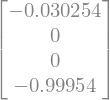

In [26]:
# Get a basis for the uncontrollable subspace
basis_u = sci.linalg.null_space(ctrb.T)
basis_u[abs(basis_u) <= 1.0e-6] = 0.0          # Correct numerical errors
basis_u = basis_u / np.sum(basis_u**2, axis=0) # Correct numerical errors
print("Uncontrollable Subspace:")
N(Matrix(basis_u), 5)

This provides us a basis of the uncontrollable subspace of $(A, B)$. As expected, the dimension of this space (the number of vectors in the basis set) is one, which is exactly equal to the number of uncontrollable modes. Additionally, the dimension of the controllable subspace and the dimension of the uncontrollable subspace sum to exactly the dimension of the state space, i.e., $3+1=4$.

Looking at these spaces, we find that $\gamma$ direction (plus a tiny bit of $\omega_\theta$ direction) is uncontrollable; however, all other directions in state space are controllable. So, is it possible to design a system that stabilizes the states along the controllable directions but allows the uncontrollable directions to evolve according to thier natural dynamics? To answer this question, we must first investigate the concepts of algebraic equilvalence, realizations, and Kalman decomposition.

### 4b. Algebraic Equivalence

Our goal is to split our state space model into a ***algebraically equivalent*** model where the controllable and uncontrollable components are seperated. Two $m\times n$ matrices, $R$ and $S$, are called algebraically equivalent if there exists an invertible $n \times n$ matrix, $P$, and an invertible $m \times m$ matrix, $Q$, such that:
$$
R = Q^{-1}SP.
$$
These are called algebraically equivalent matrices because they represent the exact same linear transformation just under two different bases.

For example, let's look at the case with square matrices. We know that a vector, $\mathbf{x}$, can be defined in two different bases, say $V$ and $W$. Let $\mathbf{x}^V$ be $\mathbf{x}$ expressed in the $V$ basis and let $\mathbf{x}^W$ be $\mathbf{x}$ expressed in the $W$ basis. Let $T$ be the ***change-of-base matrix*** that takes $W$ to $V$ such that $T\mathbf{x}^W = \mathbf{x}^V$. If $R$ and $S$ are algebraically equivalent, then they must represent the exact same linear transformation. This means that $T(S\mathbf{x}^W) = R\mathbf{x}^V$. 

It follows that 
\begin{align}
TS\mathbf{x}^W &= R\mathbf{x}^V \\
TS\mathbf{x}^W &= RT\mathbf{x}^W \\
S\mathbf{x}^W &= T^{-1}RT\mathbf{x}^W \\
S &= T^{-1}RT,
\end{align}

which is where the above definition of algebraic equivalence arises (for square matrices).

### 4c. Realizations

A ***realization*** of a state-space model is an implementation of the linearized dynamics of a system's near an equilibrium point. In other words, given some state-space model
$$
\dot{\mathbf{x}} = A\mathbf{x}+B\mathbf{u},
$$
a realization of $(A, B)$, is any double, $(\tilde{A}, \tilde{B})$, that represent the same dynamics in a different base. In terms of algebraic equivalency, a realization $(\tilde{A}, \tilde{B})$ must be algebraically equivalent to $(A, B)$.

For example, suppose there exists some change-of-base matrix, $T$, that takes the cardinal basis of the state space to some new basis, $V$:

$$
T\tilde{\mathbf{x}} = \mathbf{x}.
$$

Given this transform, we find

\begin{align}
\frac{d}{dt}\left(T\tilde{\mathbf{x}}\right) &= \dot{\mathbf{x}}\\
T \dot{\tilde{\mathbf{x}}} &= \dot{\mathbf{x}}\\
T \dot{\tilde{\mathbf{x}}} &= A\mathbf{x}+B\mathbf{u}\\
\dot{\tilde{\mathbf{x}}} &= T^{-1}\left(A\mathbf{x}+B\mathbf{u}\right)\\
\dot{\tilde{\mathbf{x}}} &= T^{-1}\left(AT\tilde{\mathbf{x}}+B\mathbf{u}\right)\\
\dot{\tilde{\mathbf{x}}} &= T^{-1}AT\tilde{\mathbf{x}}+T^{-1}B\mathbf{u}\\
\dot{\tilde{\mathbf{x}}} &= T^{-1}AT\tilde{\mathbf{x}}+T^{-1}BI\mathbf{u}.
\end{align}

If we call

\begin{align}
\tilde{A} &= T^{-1}AT \\
\tilde{B} &= T^{-1}BI,
\end{align}

from our above definition of algebraic equivalence, we conclude that $\tilde{A}$ is algebraically equivalent to $A$ and that $\tilde{B}$ is algebraically equivalent to $B$. This tells us that the system $(\tilde{A}, \tilde{B})$ does indeed represent the same dynamics as $(A, B)$, just in a different base. Therefore, $(\tilde{A}, \tilde{B})$ is a realization of $(A, B)$.

In our current model, $(A,B)$, the dynamics are represented in the standard basis, i.e., they operate on vectors expressed as linear combinations of the cardinal directions in state space. From our above analysis, if we can find a change-of-base matrix, $T$, that takes the standard basis to a basis aligned with the controllable and uncontrollable directions, we would be able to find a realization that operates on vectors expressed as linear combinations of the controllable and uncontrollable directions. Doing so would seperate the dynamics into the controllable and uncontrollable components.

### 4d. Kalman Decomposition

Such a process is called ***Kalman decomposition***. A Kalman decomposition provides a mathematical means to convert a realization of a state-space model to a new realization in which the system can be decomposed into a form with seperated controllable and uncontrollable components.

Let $\mathcal{C}$ be a matrix whose columns span the controllable subspace of some system $(A, B)$. Let $\mathcal{U}$ be a matrix whose columns span the uncontrollable subspace of some system $(A, B)$. Let $T$ be a change-of-basis matrix such that $T=\left[\mathcal{C}\ \ \ \mathcal{U}\right]$. 

How can we be sure this is a valid change-of-base matrix? Recall $\mathcal{C}$ we defined to span range of the controllability matrix and $\mathcal{U}$ was defined to span the left null space of the controllability matrix. Therefore, the range and left null space of the controllability matrix are orthogonal compliments. Because the sum of their dimensions is $4$, and given that our state space is also 4D, by the properties of othogonal compliments, we conclude that any vector in state space can be uniquely decomposed into a component in $\mathcal{C}$ and a component $\mathcal{U}$. This tells us that $T$ must be a valid change-of-basis matrix.

Given this validity, we have
$$
T^{-1}\mathbf{x} = \tilde{\mathbf{x}} = \begin{bmatrix}\mathbf{x}_\mathcal{C} \\ \mathbf{x}_\mathcal{U} \end{bmatrix},
$$
where $\mathbf{x}_\mathcal{C}$ is the projection of $\mathbf{x}$ onto the controllable subspace and $\mathbf{x}_\mathcal{U}$ is the projection of $\mathbf{x}$ onto the uncontrollable subspace. This operation seperates the state, $\mathbf{x}$, into its controllable and uncontrollable components, which is exactly what we want.

Additionally, because $T$ is a change-of-basis matrix, we can use it to generate a realization of $(A,B)$ by the procedure listed in the above section:
\begin{align}
\dot{\tilde{\mathbf{x}}} &= \tilde{A} \tilde{\mathbf{x}} + \tilde{B}\mathbf{u} \\
\tilde{A} &= \left[\mathcal{C}\ \ \ \mathcal{U}\right]^{-1}A\left[\mathcal{C}\ \ \ \mathcal{U}\right] \\
\tilde{B} &= \left[\mathcal{C}\ \ \ \mathcal{U}\right]^{-1}B.
\end{align}

We can also decompose this realization into controllable and uncontrollable blocks. To do so, all we need to do is split $\tilde{A}$ and $\tilde{B}$ into block matrices of specific sizes and split \tilde{x} into the controllable and uncontrollable elements:
\begin{align}
\dot{\tilde{\mathbf{x}}} &= \tilde{A} \tilde{\mathbf{x}} + \tilde{B}\mathbf{u} \\ 
\begin{bmatrix}\dot{\mathbf{x}_\mathcal{C}} \\ \dot{\mathbf{x}_\mathcal{U}} \end{bmatrix} &= \begin{bmatrix}A_\mathcal{C} & A_{12} \\ 0 & A_\mathcal{U}\end{bmatrix} \begin{bmatrix}\mathbf{x}_\mathcal{C} \\ \mathbf{x}_\mathcal{U} \end{bmatrix} + \begin{bmatrix}B_\mathcal{C} \\ 0 \end{bmatrix}\mathbf{u}.
\end{align}
In this decomposition, $A_\mathcal{C}$ is $m_c\times m_c$ where $m_c$ is the number of controllable modes, $A_\mathcal{U}$ is $m_u \times m_u$ where $m_u$ is the number of uncontrollable modes, $A_{12}$ is $m_c\times m_u$, the $0$ in $\tilde{A}$ is  $m_u\times m_c$, $B_\mathcal{C}$ is $m_c\times n$ where $n$ is the number of inputs to the system, and the $0$ in $\tilde{B}$ is  $m_u\times n$.

Investigating our new realization of $(A, B)$, we find that the controllable and uncontrollable components are fully seperated, which is exactly what we want! 

Let's implement this in code:

In [27]:
# Build a transform that projects state space onto the controllable and uncontrollable subspaces
T = np.hstack((basis_c, basis_u))

# Build the algebraically equivalent realization of (A, B) based on T
A_tilda = T.T @ np.array(A, dtype=float) @ T
B_tilda = T.T @ np.array(B, dtype=float)

# Correct numerical instabilities
A_tilda[abs(A_tilda) <= 1.0e-6] = 0.0 
B_tilda[abs(B_tilda) <= 1.0e-6] = 0.0 

# Get the controlled, uncontrolled, and input dimensionalities
m_c = basis_c.shape[1]
m_u = basis_u.shape[1]

# Decompose the new realization into controlled, uncontrolled, and coupling blocks
A_c = A_tilda[0:m_c, 0:m_c]
A_12 = A_tilda[0:m_c, m_c:m_c+m_u]
A_u = A_tilda[m_c:m_c+m_u:, m_c:m_c+m_u]
B_c = B_tilda[0:m_c, :]

Recall the goal of this entire process was to design a controller that only stabilizes controllable modes of $(A, B)$ while making no changes to the uncontrollable modes. Given our new realization of $(A, B)$, we can now do this via a process called ***partial state feedback***.

### 4e. Partial State Feedback

In previous projects, we have used ***full state feedback*** to stabilize systems. This means that our control inputs were based on the full set of the state variables. Conversely, in partial state feedback, only a subset of the system's state variables are used to generate control signals.

In [ ]:
# Calculate the controllability of the controllable subspace
ctrb_c = tuple(np.linalg.matrix_power(A_c,i) @ B_c for i in range(A_c.shape[0]))
ctrb_c = np.hstack(ctrb_c).astype(float)

# Get the singular value decomposition of the controllability matrix of the controllable subspace
U, s, Vh = sci.linalg.svd(ctrb_c)

# Determine controllability by comparing the number of nonzero single values to the number of controllable states
n_nonzero_singular_vals = np.sum(~np.isclose(s, 0)) # Account for numerical errors with np.isclose
is_controllable = n_nonzero_singular_vals == len(A_c)
print(f"Is Controllable: {is_controllable}")

\begin{align}
\tilde{x} &= T^{-1}x \\
\dot{\tilde{x}} &= T^{-1}\dot{x} \\
\dot{x} &= Ax+Bu \\
\dot{\tilde{x}} &= T^{-1}Ax+T^{-1}Bu \\
x &= T\tilde{x} \\
\dot{\tilde{x}} &= T^{-1}AT\tilde{x}+T^{-1}Bu \\
\tilde{A} &= T^{-1}AT \\
\tilde{B} &= T^{-1}B \\
\dot{\tilde{x}} &= \tilde{A}\tilde{x}+\tilde{B}u \\
\end{align}

\begin{align}
\dot{x}_c &= A_c x_c + A_{12} x_u + B_c u \\
\dot{x}_u &= A_u x_u = 0 \\
\therefore x_u(0) &= 0 \rightarrow x_u(t) = 0 \quad \forall t\\
u &= -K_c x_c \\
\dot{x}_c &= A_c x_c + A_{12} x_u + B_c (-K_c x_c) \\
\dot{x}_c &= (A_c - B_c K_c) x_c + A_{12} x_u\\
\dot{x}_c &= (A_c - B_c K_c) x_c \\
\end{align}

### 4a. Reference Tracking

Suppose we wanted to point our spacecraft at $\alpha=0$ and later at $\alpha=\frac{\pi}{12}$. Were our linear dynamics dependent on $\alpha$, to do this we would need to calculate a set of control gains for the two different equilibrium points and then determine a method of switching between our controllers while maintaining system stability. However, because our linear dynamics are independent of $\alpha$, we can instead utilize a method called ***reference tracking*** to drive our system to any $\alpha$ we want without modifying the controller.

The controllers we have designed so far converge the system to $0$. That is
$$
\mathbf{x}(t) \rightarrow 0\quad \text{as}\quad t \rightarrow \infty.
$$
Suppose instead we want the system to converge to something else. That is
$$
\mathbf{x}(t) \rightarrow \mathbf{x}_{des}=\begin{bmatrix}0\\0\\0\\ a \\ 0 \\ 0\end{bmatrix},\quad a\in\mathbb{R}\quad \text{as}\quad t \rightarrow \infty.
$$

To do this, we can define a new variable $\mathbf{z}=\mathbf{x}-\mathbf{x}_{des}$, and a new control law such that 
$$
\mathbf{u}=-K\mathbf{z}.
$$
Given these changes, let's look at the system dynamics:
\begin{align}
\dot{\mathbf{z}} &= \frac{d}{dt}(\mathbf{x} - \mathbf{x}_{des}) \\
&= \dot{\mathbf{x}} - 0 \\
&= \dot{\mathbf{x}}.
\end{align}

Because we already showed that our state space model is just as accurate near $(\mathbf{m}_e, \mathbf{n}_e)$ as it is near the equilibrium point $(\mathbf{m}_e+\mathbf{x}_{des}, \mathbf{n}_e)$, we know that, even when tracking $\mathbf{x}_{des}$, $\dot{\mathbf{x}}\approx A\mathbf{x}+B\mathbf{u}$. Therefore
\begin{align}
\dot{\mathbf{z}} &= \dot{\mathbf{x}} \\
&\approx A\mathbf{x}+B\mathbf{u} \\
&= A(\mathbf{z}+\mathbf{x}_{des})+B\mathbf{u} \\
&= A\mathbf{z}+B\mathbf{u}+A\mathbf{x}_{des}.
\end{align}

We also already showed that $A$ has the special property that $A\mathbf{x}_{des}=0$, therefore
\begin{align}
\dot{\mathbf{z}} &= A\mathbf{z}+B\mathbf{u}+A\mathbf{x}_{des} \\
&= A\mathbf{z}+B\mathbf{u}. \\
\end{align}

By our selected control law $\mathbf{u}=-K\mathbf{z}$, we have
\begin{align}
\dot{\mathbf{z}} &= A\mathbf{z}+B\mathbf{u} \\
&= A\mathbf{z}+B(-K\mathbf{z}) \\
&= (A-BK)\mathbf{z}.
\end{align}

We recognize this ***closed loop response matrix***, $A-BK$, as the same one from the previous pendulum cart series. As such, we have already shown that this system is ***asymptotically stable***, i.e. $\mathbf{z} \rightarrow \mathbf{0}$ as $t \rightarrow \infty$, as long as the real parts of the eigenvalues of the closed loop response matrix are negative. We have also developed methods of calculating the gain matrix $K$ to ensure this condition. Therefore, we know we can build a system such that
$$
\mathbf{z}(t) \rightarrow 0\quad \text{as}\quad t \rightarrow \infty.
$$
Recalling the definition of $\mathbf{z}$, this is identical to the statement:
$$
\mathbf{x}(t) \rightarrow \mathbf{x}_{des}\quad \text{as}\quad t \rightarrow \infty,
$$
which is exactly what we wanted.

Summarizing, we showed that if the following conditions are met:
1. Our state space model, $(A, B)$, is just as accurate near $(\mathbf{m}_e, \mathbf{n}_e)$ as it is near the equilibrium point $(\mathbf{m}_e+\mathbf{x}_{des}, \mathbf{n}_e)$ and
2. $A\mathbf{x}_{des}=0$,

the control law
$$
\mathbf{u}=-K(\mathbf{x}-\mathbf{x}_{des})
$$
results in the system behavior:
$$
\mathbf{x}(t) \rightarrow \mathbf{x}_{des}\quad \text{as}\quad t \rightarrow \infty,
$$
when the real parts of the eigenvalues of $A-BK$ are all negative.

### 4b. Implementing the Controller

We can now design and implement a controller for our system. In the Pendulum Cart series, we learned how to design and solve a ***Linear Quadratic Problem*** for our state space model to find an optimal controller, called a ***Linear Quadratic Regulator***. Repeating this process now, and again using ***Bryson's Rule*** to select an untuned ***state cost matrix, $Q$*** and untuned ***input cost matrix, $R$***, we find the following set of optimal control gains:

In [ ]:
# Import the scipy package that solve the CARE
from scipy.linalg import solve_continuous_are

# Define the state and input cost matrices
Q = np.diag([32.8, 14.6, 365.])
R = np.array([[1e6,]])

# Solve the CARE and calculate the gain matrix
P = solve_continuous_are(np.array(A_c, dtype=float), np.array(B_c, dtype=float), Q, R)
K = np.linalg.inv(R)@B_c.T@P
K = np.array(K,dtype=float)

The next step is to test our controller in simulation. This project series's provided simulation function expects us to implement a controller function that takes as argument the nonlinear state of the system, $\mathbf{m}$, and some desired yaw angle, $\alpha_{des}$, and return the torques applied to the gimbals, $\tau_\beta$ and $\tau_\gamma$. Implementing this in code:

In [ ]:
def controller(state, theta_des):
    """
    The controller function. Given some state information and a target pitch, calculates the torque to apply to the gimbals 
    that (hopefully) points the spacecraft in the desired direction.

    Parameters
    ----------
    state : dictionary of floats with the following keys
        omega_theta : float
            The angular rate of the chassis pitch in radians / second
        omega_gamma : float
            The angular rate of the gimbals in radians / second
        theta : float
            The pitch angle of the chassis in radians
        gamma : float
            The angle of the gimbals in radians
    theta_des : float
        The target pitch angle of the spacecraft in radians

    Returns
    -------
    tau_gamma : float
        The torque to apply to the gimbals
    """
    m_e = np.array([0, 0, 0, 0.5*np.pi]) # The equilibrium nonlinear state vector
    n_e = np.array([0]) # The equilibrium nonlinear input vector

    # Define a desired alpha angle
    x_des = np.array([0, theta_des, 0, 0]) - m_e

    # Build the nonlinear state vector
    m = np.array([state['omega_theta'], 
                  state['theta'], 
                  state['omega_gamma'], 
                  state['gamma'],])

    # Build the linear state vector
    x = m - m_e

    # Build the reference tracking linear state vector
    z = x - x_des

    # Transform the reference tracking linear state vector into controllable coordinates
    z_tilda = T.T @ z
    z_c = z_tilda[0:3]
    
    # Apply the feedback control law with our selected gain matrix to get the linear input vector
    u = -K@z_c

    # Convert the linear input vector into the nonlinear input vector
    n = u + n_e

    # Return the nonlinear torques as scalars
    tau_gamma = n[0]
    return tau_gamma

## 5. Running a Simulation

The backend for the simulation has already been made for you. The backend will handle building the simulation environment, running and visualizing the simulation, applying your controller's inputs, and tracking relevant data. Let's import this backend now. It is a function named `run` that is stored in a Python script named `dacmg.py`. 

In [ ]:
# Import the project's backend.
from parallel_sacmg import run

Now we are ready to run the simulation and collect data. To do this, we simply call the `run` function as pass as arguments the desired program number and the controller function we just built. The program number is an integer that selects which of the desired yaw programs will be run. Each program gives a different sequence of desired yaws as a function of time. The valid program numbers are 1-12. 1-3 are step programs, i.e., at t=2 seconds, the desired alpha instantaneously steps up to a new value. 4-6 are sequential step programs, i.e, every n seconds, the desired alpha instantaneously steps up to a new value. 7-9 are linear ramp programs, i.e., the desired alpha is a linear function of time. 10-12 are sinusoidal programs, i.e. the desired alpha follows a sine function.

Once called, the simulation will automatically run, give a sequence of desired alphas dependent on the program number, apply our controller, and return some data collected during simulation. The returned data is a dictionary with the values:

`data['time']` : list of n floats

    The time, in seconds, at which each data point is collected
    
`data['omega_alpha']` : list of n floats

    The angular rate of the spacecraft, in radians per second, at each of the n data collection points.
    
`data['omega_beta']` : list of n floats

    The angular rate of the outer gimbal, in radians per second, at each of the n data collection points.

`data['omega_gamma']` : list of n floats

    The angular rate of the inner gimbal, in radians per second, at each of the n data collection points.

`data['alpha']` : list of n floats

    The yaw angle of the spacecraft, in radians, at each of the n data collection points.
    
`data['beta']`: list of n floats

    The roll angle of the outer gimbal, in radians, at each of the n data collection points.

`data['gamma']`: list of n floats

    The pitch angle of the inner gimbal, in radians, at each of the n data collection points.

`data['tau_beta']` : list of n floats

    The torque applied to the outer gimbal, in Newton-meters, at each of the n data collection points.

`data['tau_gamma']` : list of n floats

    The torque applied to the inner gimbal, in Newton-meters, at each of the n data collection points.

`data['alpha_des']` : list of n floats

    The desired yaw angle of the spacecraft, in radians, at each of the n data collection points.

In [ ]:
# Run the simulation and collect the simulation data
data = run(1, controller)

Voila! Again our controller successfully drives the system to the desired yaw and stays there. We can confirm the by plotting the results:

In [ ]:
# Import plotting tool
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# Plot the pitch, desired pitch, and input torque as functions of time
fig, ax = plt.subplots(1)
ax.plot(data['time'], data['theta']*180/3.14, label='Pitch [deg]', lw=2.0, c='r')
ax.plot(data['time'], data['theta_des']*180/3.14, label='Desired Pitch [deg]', lw=2.0, c='r', ls='--')
ax.plot(data['time'], 1000*data['tau_gamma'], label='Torque [mN-m]', lw=2.0, c='b')
ax.legend()
ax.set_xlabel('Time [seconds]')
ax.axhline(c='k', lw=0.5)
plt.show()

## Assignment